# Define Line Trajectroy

In [28]:
from evo.core.trajectory import PosePath3D, PoseTrajectory3D
from scipy.spatial.transform import Rotation as Rot
import numpy as np
import dill
import mathUtils as math
import utils as utils
import matplotlib.pyplot as plt

# Define start and end points of the line
start_pose = np.array([-10, -5, 0])  # Starting position
end_pose = np.array([10, -5, 0])   # Ending position

T_y_shift = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1]
])

T_z_shift = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, 2],
    [0, 0, 0, 1]
])

# Generate 10 poses linearly spaced between start and end
num_poses = 10
positions = np.linspace(start_pose, end_pose, num_poses)

# Identity rotation (no rotation along the line)
identity_rotation = np.eye(3)

# Function to create a 4x4 transformation matrix
def create_transformation_matrix(position, rotation):
    T = np.eye(4)
    T[:3, :3] = rotation  # Assign rotation
    T[:3, 3] = position   # Assign translation
    return T

# Generate the original SE(3) transformation matrices
trajectory_matrices = [create_transformation_matrix(pos, identity_rotation) for pos in positions]
timestamps = np.linspace(0, num_poses - 1, num_poses)  # Fix timestamps to match poses


for i in range(0, num_poses):
    if(i % 2 == 1):
        trajectory_matrices[i] = T_z_shift @ trajectory_matrices[i]


# Create first trajectory
trajectory = PoseTrajectory3D(poses_se3=trajectory_matrices, timestamps=timestamps)
trajectory.meta["Name"] = "A"

# Define shift (translation) and rotation (Euler angles)
shift_vector = np.array([-3, 5, 0])  # Example shift (x, y, z)
euler_angles = np.radians([0, 0, 20])  # Example rotation in degrees (roll, pitch, yaw)

# Convert Euler angles to rotation matrix
rotation_matrix = Rot.from_euler('xyz', euler_angles).as_matrix()

# Apply transformation to create the second trajectory
def transform_pose(T, rotation, shift):
    new_T = np.eye(4)
    new_T[:3, :3] = rotation @ T[:3, :3]  # Apply rotation
    new_T[:3, 3] = rotation @ T[:3, 3] + shift  # Apply rotation and shift to translation
    return new_T

# Generate transformed trajectory
transformed_trajectory_matrices = [transform_pose(T, rotation_matrix, shift_vector) for T in trajectory_matrices]

# Create second trajectory
transformed_trajectory = PoseTrajectory3D(poses_se3=transformed_trajectory_matrices, timestamps=timestamps)
transformed_trajectory.meta["Name"] = "B"

# Print transformed trajectory for verification
for i, T in enumerate(transformed_trajectory_matrices):
    print(f"Transformed Pose {i}:\n{T}\n")


Transformed Pose 0:
[[  0.93969262  -0.34202014   0.         -10.68682549]
 [  0.34202014   0.93969262   0.          -3.11866454]
 [  0.           0.           1.           0.        ]
 [  0.           0.           0.           1.        ]]

Transformed Pose 1:
[[ 0.93969262 -0.34202014  0.         -8.59861967]
 [ 0.34202014  0.93969262  0.         -2.35861977]
 [ 0.          0.          1.          2.        ]
 [ 0.          0.          0.          1.        ]]

Transformed Pose 2:
[[ 0.93969262 -0.34202014  0.         -6.51041384]
 [ 0.34202014  0.93969262  0.         -1.59857501]
 [ 0.          0.          1.          0.        ]
 [ 0.          0.          0.          1.        ]]

Transformed Pose 3:
[[ 0.93969262 -0.34202014  0.         -4.42220802]
 [ 0.34202014  0.93969262  0.         -0.83853025]
 [ 0.          0.          1.          2.        ]
 [ 0.          0.          0.          1.        ]]

Transformed Pose 4:
[[ 0.93969262 -0.34202014  0.         -2.3340022 ]
 [ 0.3420

In [29]:
from scipy.spatial.transform import Rotation as rot

def kabsch_algorithm(traj_a_poses_se3, traj_b_poses_se3, weights = None):
    """
    Perform the Kabsch algorithm to find the optimal rotation matrix and translation vector
    that aligns two PoseTrajectory3D objects.
    
    Args:
        traj_a (PoseTrajectory3D): The first trajectory (source).
        traj_b (PoseTrajectory3D): The second trajectory (target).
    
    Returns:
        R (np.ndarray): The optimal rotation matrix (3x3).
        t (np.ndarray): The optimal translation vector (3x1).
    """
    
    #assert len(traj_a.poses_se3) == len(traj_b.poses_se3), "Trajectories must have the same number of poses."
    
    # Extract the positions from the PoseTrajectory3D objects
    positions_a = traj_a_poses_se3.positions_xyz.T
    positions_b = traj_b_poses_se3.positions_xyz.T

    if weights is None:
        # Compute the centroids of each set of positions
        centroid_a = np.mean(positions_a, axis=1, keepdims=True)  # Shape (3, 1)
        centroid_b = np.mean(positions_b, axis=1, keepdims=True)  # Shape (3, 1)
    
    else:
    # Compute the weighted centroids
        weights = np.array(weights)  # Ensure weights is a NumPy array
        weights_normalized = weights / np.sum(weights)  # Normalize weights to sum to 1

        centroid_a = np.sum(positions_a * weights_normalized, axis=1, keepdims=True)  # Shape (3, 1)
        centroid_b = np.sum(positions_b * weights_normalized, axis=1, keepdims=True)  # Shape (3, 1)

    # Center the positions by subtracting the centroids
    positions_a_centered = positions_a - centroid_a  # Shape (3, N)
    positions_b_centered = positions_b - centroid_b  # Shape (3, N)

    R,_, sensitivity= rot.align_vectors(positions_b_centered.T, positions_a_centered.T, weights, return_sensitivity=True)

    R = R.as_matrix()

    
    # Compute the translation vector t
    t = centroid_b - np.dot(R, centroid_a)

    return R, t.T, sensitivity

In [30]:
r,t, S =  kabsch_algorithm(traj_a_poses_se3=trajectory, traj_b_poses_se3=transformed_trajectory)

# Compute the rank (number of nonzero singular values)
rank = np.sum(S > 1e-10)  # Small threshold to avoid numerical precision issues

# Print results
print(f"Singular Values: {S}")
print(f"Rank of the position matrix: {rank}")


Singular Values: [[0.09134192 0.03237376 0.00264289]
 [0.03237376 0.01417883 0.00096193]
 [0.00264289 0.00096193 0.00253125]]
Rank of the position matrix: 9


In [31]:
# Extract positions from both trajectories
positions_A = np.array([T[:3, 3] for T in trajectory.poses_se3])  # Extract translations (x, y, z) from trajectory A
positions_B = np.array([T[:3, 3] for T in transformed_trajectory.poses_se3])  # Extract from trajectory B


# Compute the Singular Value Decomposition (SVD)
U, S, Vt = np.linalg.svd(positions_A.T @ positions_B)

# Compute the rank (number of nonzero singular values)
rank = np.sum(S > 1e-10)  # Small threshold to avoid numerical precision issues

# Print results
print(f"Singular Values: {S}")
print(f"Rank of the position matrix: {rank}")

Singular Values: [411.21463344  65.71249961   5.2962797 ]
Rank of the position matrix: 3


# Visualization

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


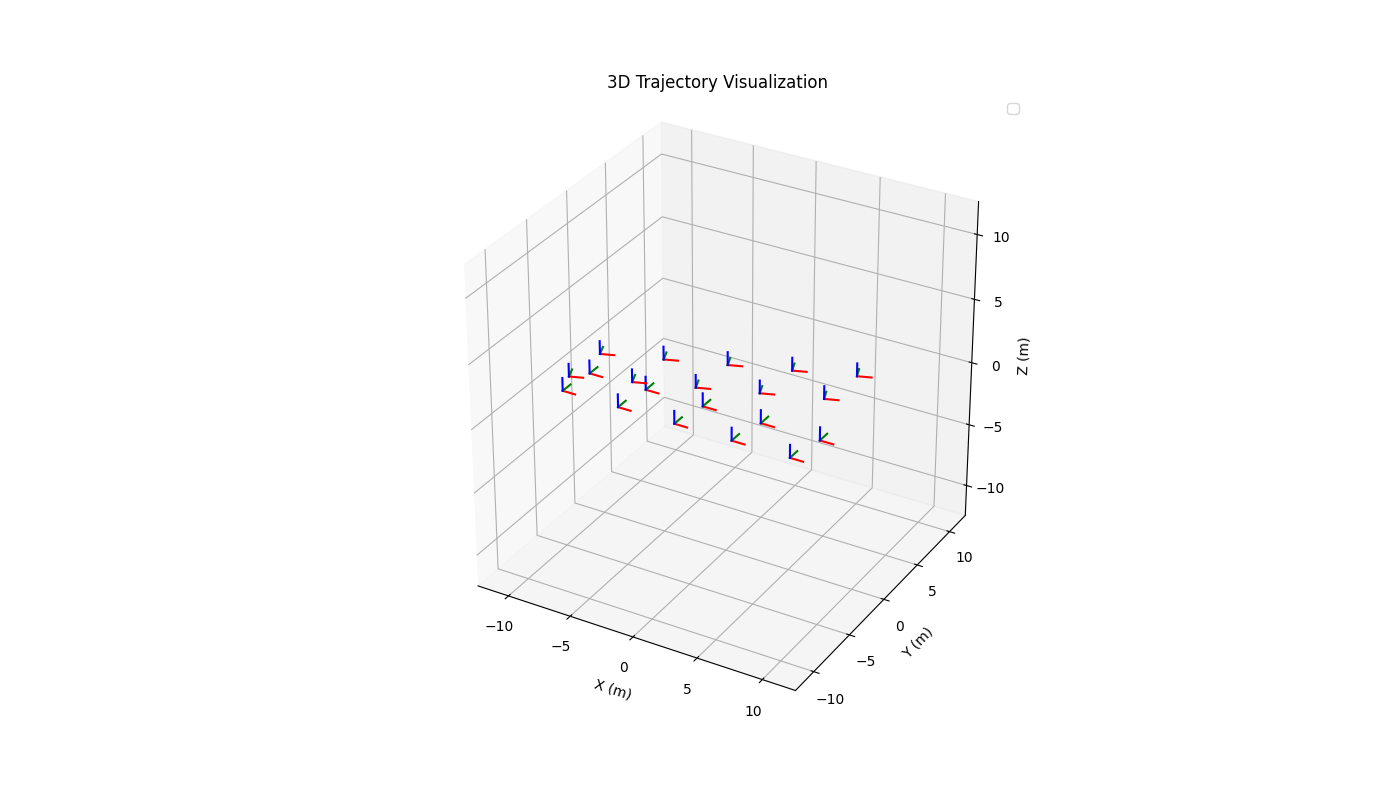

In [32]:
%matplotlib inline
%matplotlib widget 

plt.close('all')

mode_3D = True
fig = plt.figure(figsize=(14, 8))
grid = fig.add_gridspec(1,1)
ax_trajectory = fig.add_subplot(grid[0, 0], projection='3d' if mode_3D else None)

utils.plot_trajectory(fig, ax_trajectory, trajectory, mode_3D, 2.0, True, None)
utils.plot_trajectory(fig, ax_trajectory, transformed_trajectory, mode_3D, 2.0, True, None)
ax_trajectory.set_xlim(-12,12)
ax_trajectory.set_ylim(-12,12)
ax_trajectory.set_zlim(-12,12)
ax_trajectory.set_aspect('equal')
ax_trajectory.legend()